#### **Denoising Autoencoder**

It is a kind of autoencoder in which we learn the robust representations from the reconstructed clear input obtained from the corrupted input image by adding the noise to the input image.

Noisy Image → Encoder → Latent Space → Decoder → Clean Image

#### **Steps used in this Algorithm**

1. Import all the necessary Libraries

2. Load the dataset

3. Do Data Preprocessing and normalize the data

4. Flatten Images

5. Add Noise to Images

6. Model Architecture and build the Denoising Autoencoder model

7. Compile the Denoising Model

8. Train the Denoising Model

9. Evaluate the Denoising model

10. Plot the accuracy vs loss

11. Reconstruct Images Using the Trained Model

12. Visualize Original vs Reconstructed Images

Encoder ----------> It plays an important role in compressing the input features

Decoder ----------> It plays an important role in reconstructing the original image


#### **Step 1: Import all the necessary Libraries**

In [86]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from   tensorflow.keras.datasets   import mnist
from   tensorflow.keras.models     import Sequential
from   tensorflow.keras.layers     import Dense, Dropout,BatchNormalization,Flatten,Reshape
from   tensorflow.keras.optimizers import Adam

#### **OBSERVATIONS:**

1.  mnist ------> It is the dataset that represents the handwritten digits.

2.  Sequential ----> It is a sequential model that has a linear stack of layers.

3.  Dense --------> It has a dense connected layer of neurons

4.  Dropout -------> It is done to prevent the overfitting

5.  BatchNormalization -----> It is used to speed up the neural network training and improve the speed.

6.  Flatten -------> It is used to convert the 2D or 3D feature vectors into 1D vectors.

7.  Adam ------>

  (a.)  It is an optimizer that is used to update the weights during backpropogation.

  (b.)  It optimizes the learning rate so as to improve the convergence speed.

#### **Step 2: Load the dataset**

In [87]:
#### Load the dataset
(X_train, Y_train),(X_test, Y_test)=mnist.load_data()

In [88]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [89]:
X_test

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [90]:
print("Shape of the input training data is", X_train.shape)
print("Shape of the input testing  data is", X_test.shape)

Shape of the input training data is (60000, 28, 28)
Shape of the input testing  data is (10000, 28, 28)


In [91]:
Y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [92]:
Y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [93]:
print("Shape of the output training data is", Y_train.shape)
print("Shape of the output testing  data is", Y_test.shape)

Shape of the output training data is (60000,)
Shape of the output testing  data is (10000,)


#### **OBSERVATIONS:**

1.  The mnist dataset is divided into the training and the testing data.

    (a.)  the training data has 60,000 training images

    (b.)  the testing data has 10,000 testing images.

2. The input data is of the shape (No of images, pixel height, pixel width).

3.  The output data is of the shape of (No of images,).

4.  The input training data has 60,000 training images with 28 * 28 pixels

5.  The input testing data has 10,000 testing data images with 28 * 28 pixels.

6.  The Y_train and Y_test are the outputs that are not used in Autoencoders as the Autoencoder is used in unsupervised learning.

#### **Step 3: Do Data Preprocessing and normalize the data**

In [94]:
#### Data Preprocessing and normalize the inputs
X_train = X_train.astype('float32')/255.0

In [95]:
X_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [96]:
X_test  = X_test.astype('float32')/255.0

In [97]:
X_test

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

#### **OBSERVATIONS:**

1.  Initially each pixel value ranges from 0 to 255.

2.  But after normalizing the pixel data i.e dividing the pixel data by 255.0, each pixel data has been reduced to 0-1 .

3.  The normalization has been done so that these normlaized values can be easily be fed into the neural network model and the model can easily train them.

#### **Step 4: Flatten Images**

In [98]:
X_train.shape

(60000, 28, 28)

In [99]:
X_train.ndim

3

In [100]:
#### Dimension of the input data
print("Dimension  of the input training data before reshaping is:", X_train.ndim)
print("Dimnension of the input testing  data before reshaping is:", X_test.ndim)

Dimension  of the input training data before reshaping is: 3
Dimnension of the input testing  data before reshaping is: 3


In [101]:
#### Shape of the input data
print("Shape of the input training data before reshaping is:", X_train.shape)
print("Shape of the input testing  data before reshaping is:", X_test.shape)

Shape of the input training data before reshaping is: (60000, 28, 28)
Shape of the input testing  data before reshaping is: (10000, 28, 28)


In [102]:
#### perform the flattening on the input images
X_train = X_train.reshape(len(X_train),(28*28))
X_test  = X_test.reshape(len(X_test),(28*28))

In [103]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [104]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [105]:
X_train.shape

(60000, 784)

In [106]:
X_train.ndim

2

In [107]:
X_test.shape

(10000, 784)

In [108]:
X_test.ndim

2

In [109]:
#### Shape of the input data
print("Shape of the input training data after reshaping is:", X_train.shape)
print("Shape of the input testing  data after reshaping is:", X_test.shape)

Shape of the input training data after reshaping is: (60000, 784)
Shape of the input testing  data after reshaping is: (10000, 784)


In [110]:
#### Dimension of the input data
print("Dimension  of the input training data after reshaping is:", X_train.ndim)
print("Dimnension of the input testing  data after reshaping is:", X_test.ndim)

Dimension  of the input training data after reshaping is: 2
Dimnension of the input testing  data after reshaping is: 2


#### **OBSERVATIONS:**

1.  Here the input training data is of the form (60000,28,28)

2.  After performing the flattening operation it is converted into (60000,784)

3.  Here the input testing data is of the form (10000,28,28)

4.  After performing the flattening operation it is converted into (10000,784)

5. Now both the input training and testing data has the input in form of 2d because the fully dense connected layer expects the input to be in form of 2D.

#### **Step 5: Add Noise to Images**

In [111]:
#### Adding the noise to the input image
noise_factor = 0.2

### Adding the noise to the input training and testing data
X_train_noisy = X_train + noise_factor * np.random.normal(loc = 0.0, scale = 1.0, size = X_train.shape)
X_test_noisy  = X_test + noise_factor  * np.random.normal(loc = 0.0, scale = 1.0, size = X_test.shape)

In [112]:
X_train_noisy

array([[-0.18129241,  0.20158074, -0.08105633, ..., -0.48286148,
        -0.02412657, -0.08934484],
       [-0.22884741,  0.06858016,  0.50856544, ..., -0.18265872,
        -0.40407866,  0.07280678],
       [-0.00078521, -0.16698973,  0.07104519, ...,  0.00850625,
         0.28064473, -0.1501121 ],
       ...,
       [ 0.30134892,  0.05537419,  0.14978423, ..., -0.19793753,
        -0.20768411, -0.2563475 ],
       [-0.00784683,  0.21506007,  0.11540129, ...,  0.046941  ,
         0.1390809 ,  0.12891087],
       [-0.19633058,  0.03839293, -0.17612615, ..., -0.1939712 ,
         0.27947842, -0.14285178]])

In [113]:
X_test_noisy

array([[-0.33450021, -0.24815086,  0.22366199, ..., -0.00165958,
         0.01708351, -0.05277535],
       [-0.21616048,  0.04943915,  0.01804324, ..., -0.06334712,
        -0.06461737,  0.53374157],
       [-0.23249027, -0.23588372,  0.17926418, ..., -0.23221682,
        -0.09120857, -0.12686713],
       ...,
       [-0.31255411, -0.06716532,  0.16739352, ..., -0.00554006,
        -0.0025962 ,  0.02237324],
       [-0.23765113, -0.05567049, -0.03324889, ..., -0.10836361,
         0.16943566,  0.13807487],
       [ 0.13060887,  0.30853754,  0.23714389, ..., -0.15919898,
         0.11534254, -0.07583055]])

In [114]:
#### Making all the picel values valid
X_train_noisy = np.clip(X_train_noisy,0.,1.)

In [115]:
X_train_noisy

array([[0.        , 0.20158074, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.06858016, 0.50856544, ..., 0.        , 0.        ,
        0.07280678],
       [0.        , 0.        , 0.07104519, ..., 0.00850625, 0.28064473,
        0.        ],
       ...,
       [0.30134892, 0.05537419, 0.14978423, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.21506007, 0.11540129, ..., 0.046941  , 0.1390809 ,
        0.12891087],
       [0.        , 0.03839293, 0.        , ..., 0.        , 0.27947842,
        0.        ]])

In [116]:
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

In [117]:
X_test_noisy

array([[0.        , 0.        , 0.22366199, ..., 0.        , 0.01708351,
        0.        ],
       [0.        , 0.04943915, 0.01804324, ..., 0.        , 0.        ,
        0.53374157],
       [0.        , 0.        , 0.17926418, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.16739352, ..., 0.        , 0.        ,
        0.02237324],
       [0.        , 0.        , 0.        , ..., 0.        , 0.16943566,
        0.13807487],
       [0.13060887, 0.30853754, 0.23714389, ..., 0.        , 0.11534254,
        0.        ]])

#### **OBSERVATIONS:**

1.  clip function has been applied on the input noise data to

    (a.)  make all the pixel values between 0 to 1.

    (b.)  make sure that any pixel > 1 should be 1

    (c.)  any pixel < 0 should be 0 and the rest should be unchanged.

    (d.)  make all the pixel values as valid

    (e.) This is because the original mnist image data is normlaized between 0 to 1. So to make it compatible with the noisy input data. This noisy input data is scaled between 0 to 1.

#### **Step 6: Model Architecture and build the Denoising Autoencoder model**

In [118]:
#### Construct the denoising autoencoder model
model = Sequential([
    ############################# Encoder #########################################
    Dense(units=128,activation='relu',input_shape=(784,)),
    Dense(units=64,activation='relu'),

    ############################# Decoder #########################################
    Dense(units=128,activation='relu'),
    Dense(units=784, activation='sigmoid')
])

In [119]:
model

<Sequential name=sequential_2, built=True>

#### **OBSERVATIONS:**

1.  The object for the deoising autoencoder sequential model has been initialized.

2.  First of all we have the total input features as 784

3.  Then we compress 784 features ------> 128 features

4.  Again we compress 128 features -------> 64 features

5.  The above process is known as encoding.

6.  Then begins with the decoding process

7.  We decode the features from 64 --------------> 128 features

8.  Again we decode from 128 ---------------------> 784 features

9.  This process is known as decoding

10. So here in this model, we try to compress the size of the corrupted input image so as to extract all the essential information from it and then we contruct the original image from the corrupted input image

In [120]:
#### get the summary of the model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

#### **Step 7: Compile the Denoising Model**

In [121]:
#### compile the model
model.compile(
    optimizer   =    'adam'                         ,
    loss        =    'binary_crossentropy'          ,
    metrics     =    ['accuracy']
)

#### **OBSERVATIONS:**

1. The model has been made ready for the training purpose with the help of the following parameters.

    (a.) optimizer = 'adam' . It is used to make the learning rate as dynamic and improves the convergence speed.

    (b.) loss = 'binary_crossentropy'. It is a binary loss function as it is used to solve the binary classification problem.

    (c.) metrics = 'accuracy'. It is used to evaluate the performance of the model

#### **Step 8: Train the Denoising Model**

In [122]:
#### Train the model
history=model.fit(
    X_train                                   ,
    X_train_noisy                             ,
    epochs            =      10               ,
    batch_size        =      256              ,
    validation_split  =      0.2              ,
    verbose           =      1
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.0014 - loss: 0.4153 - val_accuracy: 0.0012 - val_loss: 0.3643
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0017 - loss: 0.3519 - val_accuracy: 0.0030 - val_loss: 0.3450
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0026 - loss: 0.3415 - val_accuracy: 0.0028 - val_loss: 0.3392
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0031 - loss: 0.3368 - val_accuracy: 0.0033 - val_loss: 0.3354
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.0032 - loss: 0.3338 - val_accuracy: 0.0033 - val_loss: 0.3331
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0033 - loss: 0.3317 - val_accuracy: 0.0033 - val_loss: 0.3312
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0034 - loss: 0.3300 - val_accuracy: 0.0028 - val_loss: 0.3298
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.0036 - loss: 0.3287 - val_accu

In [123]:
history

#### **OBSERVATIONS:**

1. The denoising autoencoder model has been trained with the help of the following parameters:-

(a.) training data ----------------> X_train, X_train_noisy

.   X_train_noisy ------->  Corrupted input image     (input)

.   X_train       -------> Original clean input image  (output)

2.  It has the corrupted image as the input, performs the encoding and then reconstructs the original image from it as the output.

Then the reconstructed image is compared with the original image.

(b.) epochs = 10 ------------> 10 iterations are needed to train the model

(c.) batch_size = 256 -------> the weights get updated after every 256 samples

(d.) validation_split = 0.2 --------> 20 % of the data is used for validation where the model sees the performance on the unseen data

#### **Step 9: Evaluate the Denoising model**

In [124]:
loss, accuracy = model.evaluate(X_test, X_test_noisy, verbose=0)

print(f"Loss is : {loss:.4f}")
print(f"Accuracy is: {accuracy:.4f}")

Loss is : 0.3266
Accuracy is: 0.0027


#### **Step 10: Plot the accuracy vs loss**

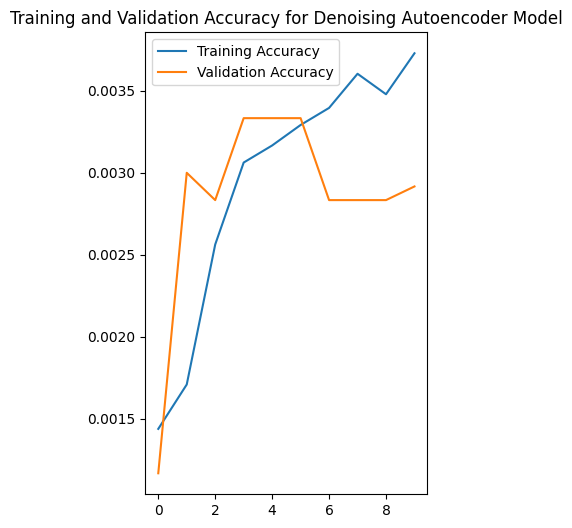

In [125]:
plt.figure(figsize=(8,6))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy for Denoising Autoencoder Model')
plt.legend()
plt.show()

#### **OBSERVATIONS:**

1. With the increase in the number of epochs, the accuracy and the validation accuracy of the model increases.

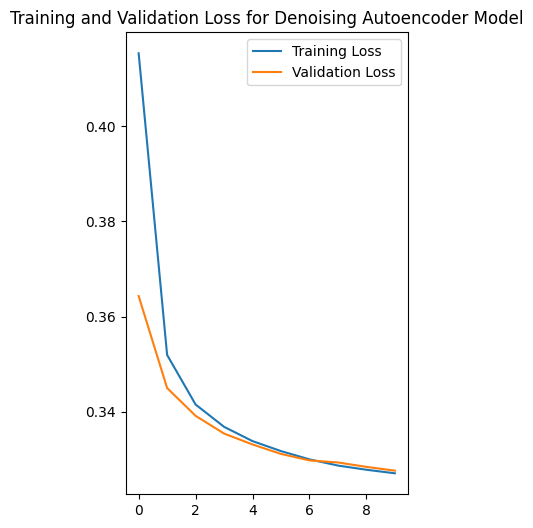

In [126]:
plt.figure(figsize=(8,6))
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss for Denoising Autoencoder Model')
plt.legend()
plt.show()

#### **OBSERVATIONS:**

1. With the increase in the number of epochs, the loss and the validation loss of the model decreases.

#### **Step 11: Reconstruct Images Using the Trained Model**

In [127]:
#### predict the output for the model
decoded_imgs = model.predict(X_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [128]:
decoded_imgs

array([[0.10031119, 0.10571361, 0.08594777, ..., 0.10139218, 0.0925316 ,
        0.09552692],
       [0.09337603, 0.07532148, 0.07666374, ..., 0.10330604, 0.09025048,
        0.07806113],
       [0.09947348, 0.08882749, 0.08304587, ..., 0.0963694 , 0.09676627,
        0.09220815],
       ...,
       [0.09299476, 0.07680309, 0.07938891, ..., 0.10599652, 0.09534233,
        0.09003942],
       [0.08892745, 0.08301587, 0.07437651, ..., 0.09250244, 0.08747898,
        0.08312666],
       [0.11978756, 0.11468051, 0.08964371, ..., 0.12486601, 0.10860061,
        0.10540462]], dtype=float32)

#### **Step 12: Visualize Original vs Reconstructed Images**

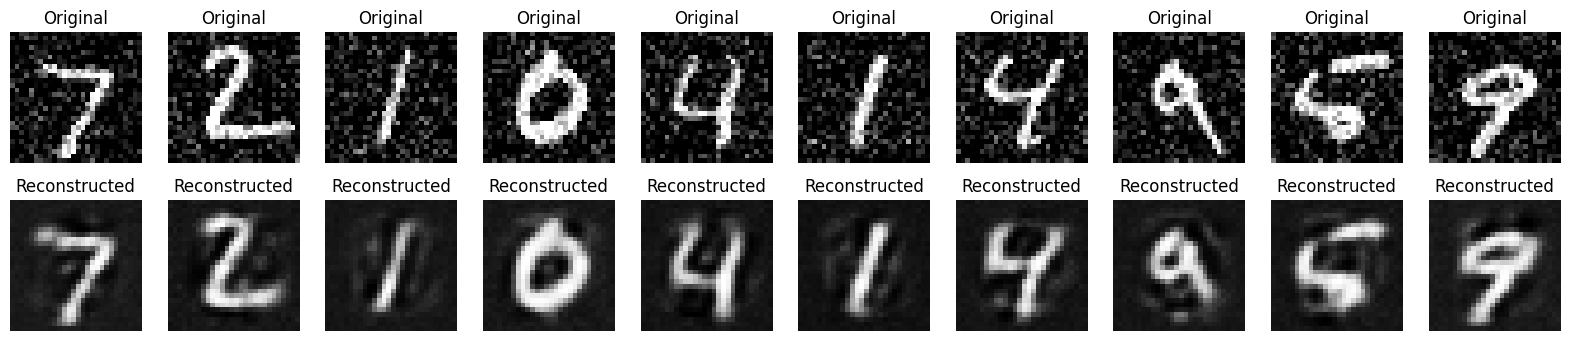

In [129]:
n = 10  # Show 10 images
plt.figure(figsize=(20,4))

for i in range(n):
    # Display original corrupted noisy input image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap="gray")
    ax.set_title("Original")
    plt.axis("off")

    # Display reconstructed input clean image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    ax.set_title("Reconstructed")
    plt.axis("off")

plt.show()

#### **OBSERVATIONS:**

1. Here we have performed the visualization between the Original vs Reconstructed Image.

2.  After performing the Denoising Autoencoder, we can see that the original and the reconstructed image looks the same.

3. Here the noise has been added to the input to make it look corrupted, then encoding and decoding has been formed to reconstruct the original image from the corrupted image.

4.  So the Denoising Autoencoder works fine